## 1. Import Library

In [2]:
import os
import glob
import json
import matplotlib.pyplot as plt
from collections import defaultdict

In [ ]:
# os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Set to the GPU you want to use (default = 0)

## PATH FOLDER

In [ ]:
# Path konfigurasi
CONFIG     = "01_asset_tools/ciis_7.py"       # file config training
WORK_DIR   = "02_work_dirs/<sesuaikan>"       # folder hasil training --> SESUAIKAN DENGAN FORMAT ANDA

# File plot hasil training
PLOT_OUT = '04_lampiran/training_' + os.path.basename(WORK_DIR) + '.png'

## 2. Training via bash

In [ ]:
!python mmaction2/tools/train.py {CONFIG} \
    --work-dir {WORK_DIR} \
    --seed 0 \
    # --resume

05/21 15:16:38 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.8.18 (default, Sep 11 2023, 13:40:15) [GCC 11.2.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 0
    GPU 0,1: NVIDIA GeForce RTX 3090
    CUDA_HOME: /usr/local/cuda-12.3
    NVCC: Cuda compilation tools, release 12.3, V12.3.107
    GCC: gcc (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0
    PyTorch: 2.2.1
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2023.1-Product Build 20230303 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v3.3.2 (Git Hash 2dc95a2ad0841e29db8b22fbccaf3e5da7992b01)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX2
  - CUDA Runtime 12.1
  - NVCC architecture flags: -gencode;arch=compute_50,code=sm_50;-g

## 3. Cek file JSON

In [ ]:
# Cari file log json
log_files = sorted([
    f for f in glob.glob(f"{WORK_DIR}/**/vis_data/*.json", recursive=True)
    if os.path.basename(f) != 'scalars.json'
])
print("File LOG yang ditemukan:")
for f in log_files:
    print(f"  {f}")

# Baca log
def read_log(log_path):
    train_epochs, train_loss, train_top1, train_top5 = [], [], [], []
    train_lr, train_grad_norm, train_time, train_data_time = [], [], [], []
    val_steps, val_top1, val_top5, val_mean1 = [], [], [], []

    with open(log_path, 'r') as f:
        for line in f:
            log = json.loads(line.strip())
            if 'epoch' in log:
                train_epochs.append(log['epoch'])
                train_loss.append(log['loss'])
                train_top1.append(log['top1_acc'])
                train_top5.append(log['top5_acc'])
                train_lr.append(log['lr'])
                train_grad_norm.append(log['grad_norm'])
                train_time.append(log['time'])
                train_data_time.append(log['data_time'])
            elif 'acc/top1' in log:
                val_steps.append(log['step'])
                val_top1.append(log['acc/top1'])
                val_top5.append(log['acc/top5'])
                val_mean1.append(log['acc/mean1'])

    return (train_epochs, train_loss, train_top1, train_top5,
            train_lr, train_grad_norm, train_time, train_data_time,
            val_steps, val_top1, val_top5, val_mean1)

def filter_after(data_tuple, last_epoch):
    (te, tl, tt1, tt5, tlr, tgn, ttm, tdt,
     vs, vt1, vt5, vm1) = data_tuple
    idx  = [i for i, e in enumerate(te) if e > last_epoch]
    vidx = [i for i, s in enumerate(vs) if s > last_epoch]
    return ([te[i] for i in idx], [tl[i] for i in idx],
            [tt1[i] for i in idx], [tt5[i] for i in idx],
            [tlr[i] for i in idx], [tgn[i] for i in idx],
            [ttm[i] for i in idx], [tdt[i] for i in idx],
            [vs[i] for i in vidx], [vt1[i] for i in vidx],
            [vt5[i] for i in vidx], [vm1[i] for i in vidx])

def combine(r1, r2):
    return tuple(a + b for a, b in zip(r1, r2))

# Gabungkan semua file log json jika pelatihan dilakukan tidak secara kontinu
combined = read_log(log_files[0])
for path in log_files[1:]:
    last_epoch = combined[0][-1] if combined[0] else 0
    combined = combine(combined, filter_after(read_log(path), last_epoch))

(train_epochs, train_loss, train_top1, train_top5,
 train_lr, train_grad_norm, train_time, train_data_time,
 val_steps, val_top1, val_top5, val_mean1) = combined

print(f"\nHasil gabungan:")
print(f"Train: epoch {train_epochs[0]} - {train_epochs[-1]} ({len(train_epochs)} epoch)")
print(f"Val  : {len(val_steps)} titik validasi")

## 4. Plot Evaluasi

  Sudah mencapai epoch   : 300
  Learning rate saat ini : 0.010000
  Grad norm saat ini     : 0.5316

[ Training — Epoch Terakhir ]
  Loss         : 0.0191
  Top1 Acc     : 1.0000
  Top5 Acc     : 1.0000
  Waktu/iter   : 0.475 s
  Data load    : 0.084 s
  GPU compute  : 0.391 s

[ Validasi — Epoch Terakhir ]
  Epoch        : 300
  Top1 Acc     : 0.9483
  Top5 Acc     : 0.9972
  Mean Acc     : 0.9469

[ Hasil Terbaik ]
  Best Val Top1  : 0.9494  (epoch 270)
  Best Val Mean1 : 0.9479  (epoch 270)

[ Deteksi Overfitting ]
  Gap (train-val) saat ini : 0.0517
  STATUS: ⚠️  Sedikit overfitting, pantau terus


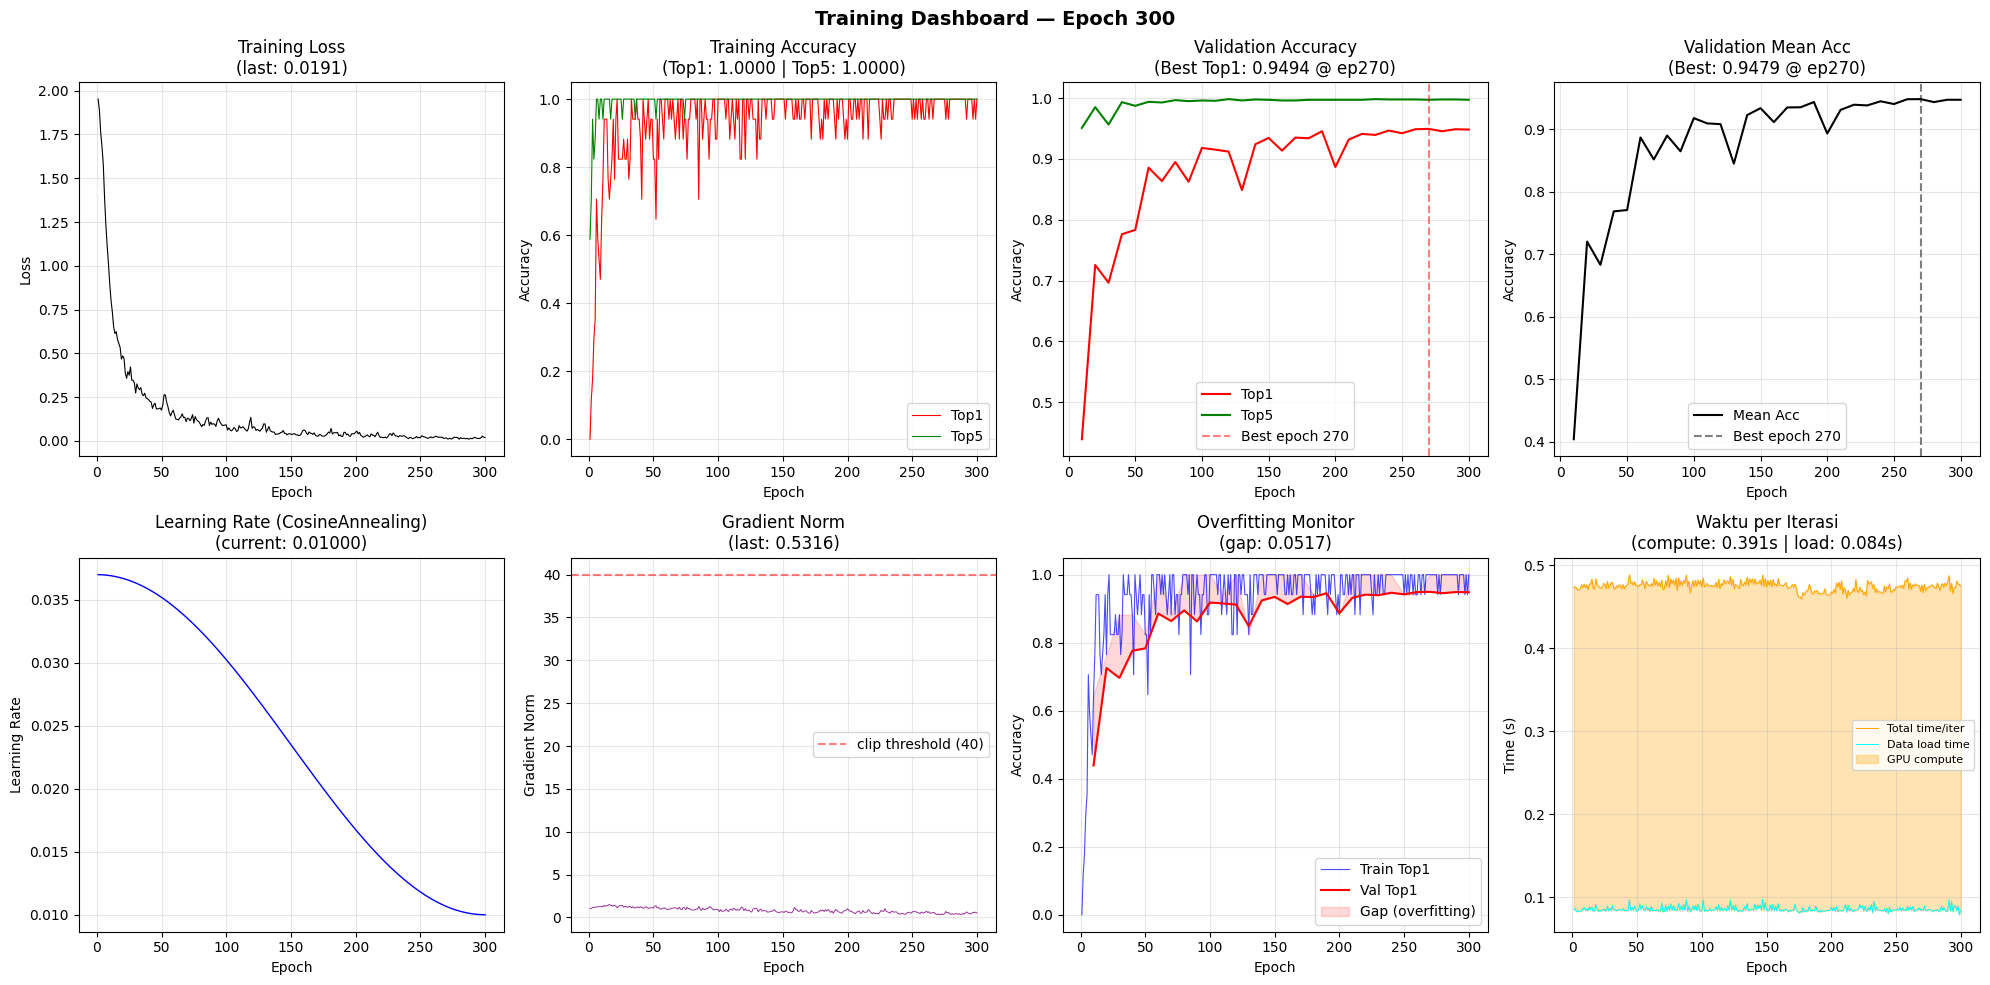

Dashboard disimpan ke 04_lampiran/training_dashboard-gab3-1sx.png


In [ ]:
# Data containers
# train_epochs, train_loss, train_top1, train_top5 = [], [], [], []
# train_lr, train_grad_norm, train_time, train_data_time = [], [], [], []
# val_steps, val_top1, val_top5, val_mean1 = [], [], [], []

# with open(log_path, 'r') as f:
#     for line in f:
#         log = json.loads(line.strip())
        
#         if 'epoch' in log:
#             train_epochs.append(log['epoch'])
#             train_loss.append(log['loss'])
#             train_top1.append(log['top1_acc'])
#             train_top5.append(log['top5_acc'])
#             train_lr.append(log['lr'])                   # ← BARU
#             train_grad_norm.append(log['grad_norm'])     # ← BARU
#             train_time.append(log['time'])               # ← BARU
#             train_data_time.append(log['data_time'])     # ← BARU
        
#         elif 'acc/top1' in log:
#             val_steps.append(log['step'])
#             val_top1.append(log['acc/top1'])
#             val_top5.append(log['acc/top5'])
#             val_mean1.append(log['acc/mean1'])

# Statistik Lengkap
best_val_top1     = max(val_top1)
best_val_epoch    = val_steps[val_top1.index(best_val_top1)]
best_val_mean1    = max(val_mean1)
best_mean_epoch   = val_steps[val_mean1.index(best_val_mean1)]

# Interpolasi train acc di epoch validasi untuk cek overfitting
train_top1_by_epoch = dict(zip(train_epochs, train_top1))
val_train_top1 = [train_top1_by_epoch[e] for e in val_steps if e in train_top1_by_epoch]
val_steps_matched = [e for e in val_steps if e in train_top1_by_epoch]  # ← sinkron
gap_overfitting = [t - v for t, v in zip(val_train_top1, val_top1[:len(val_train_top1)])]

print("=" * 60)
print(f"  Sudah mencapai epoch   : {train_epochs[-1]}")
print(f"  Learning rate saat ini : {train_lr[-1]:.6f}")
print(f"  Grad norm saat ini     : {train_grad_norm[-1]:.4f}")
print()
print("[ Training — Epoch Terakhir ]")
print(f"  Loss         : {train_loss[-1]:.4f}")
print(f"  Top1 Acc     : {train_top1[-1]:.4f}")
print(f"  Top5 Acc     : {train_top5[-1]:.4f}")
print(f"  Waktu/iter   : {train_time[-1]:.3f} s")
print(f"  Data load    : {train_data_time[-1]:.3f} s")
print(f"  GPU compute  : {train_time[-1] - train_data_time[-1]:.3f} s")
print()
print("[ Validasi — Epoch Terakhir ]")
print(f"  Epoch        : {val_steps[-1]}")
print(f"  Top1 Acc     : {val_top1[-1]:.4f}")
print(f"  Top5 Acc     : {val_top5[-1]:.4f}")
print(f"  Mean Acc     : {val_mean1[-1]:.4f}")
print()
print("[ Hasil Terbaik ]")
print(f"  Best Val Top1  : {best_val_top1:.4f}  (epoch {best_val_epoch})")
print(f"  Best Val Mean1 : {best_val_mean1:.4f}  (epoch {best_mean_epoch})")
print()
print("[ Deteksi Overfitting ]")
print(f"  Gap (train-val) saat ini : {gap_overfitting[-1]:.4f}")
if gap_overfitting[-1] > 0.15:
    print("  STATUS: ⚠️  OVERFITTING — gap train-val terlalu besar")
elif gap_overfitting[-1] > 0.05:
    print("  STATUS: ⚠️  Sedikit overfitting, pantau terus")
else:
    print("  STATUS: ✅  Generalisasi baik")
print("=" * 60)

# Plot 8 Grafik
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle(f'Training Dashboard — Epoch {train_epochs[-1]}', 
             fontsize=14, fontweight='bold')

# 1. Training Loss
ax = axes[0, 0]
ax.plot(train_epochs, train_loss, linewidth=0.8, color='black')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title(f'Training Loss\n(last: {train_loss[-1]:.4f})')
ax.grid(True, alpha=0.3)

# 2. Training Accuracy
ax = axes[0, 1]
ax.plot(train_epochs, train_top1, linewidth=0.8, color='red', label='Top1')
ax.plot(train_epochs, train_top5, linewidth=0.8, color='green', label='Top5')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title(f'Training Accuracy\n(Top1: {train_top1[-1]:.4f} | Top5: {train_top5[-1]:.4f})')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Validation Accuracy
ax = axes[0, 2]
ax.plot(val_steps, val_top1, linewidth=1.5, color='red', label='Top1')
ax.plot(val_steps, val_top5, linewidth=1.5, color='green', label='Top5')
ax.axvline(x=best_val_epoch, color='red', linestyle='--', alpha=0.5, 
           label=f'Best epoch {best_val_epoch}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title(f'Validation Accuracy\n(Best Top1: {best_val_top1:.4f} @ ep{best_val_epoch})')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Validation Mean Accuracy
ax = axes[0, 3]
ax.plot(val_steps, val_mean1, linewidth=1.5, color='black', label='Mean Acc')
ax.axvline(x=best_mean_epoch, color='black', linestyle='--', alpha=0.5,
           label=f'Best epoch {best_mean_epoch}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title(f'Validation Mean Acc\n(Best: {best_val_mean1:.4f} @ ep{best_mean_epoch})')
ax.legend()
ax.grid(True, alpha=0.3)

# 5. Learning Rate ← BARU
ax = axes[1, 0]
ax.plot(train_epochs, train_lr, linewidth=1.0, color='blue')
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_title(f'Learning Rate (CosineAnnealing)\n(current: {train_lr[-1]:.5f})')
ax.grid(True, alpha=0.3)

# 6. Gradient Norm ← BARU
ax = axes[1, 1]
ax.plot(train_epochs, train_grad_norm, linewidth=0.7, color='purple', alpha=0.8)
ax.axhline(y=40, color='red', linestyle='--', alpha=0.5, label='clip threshold (40)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Gradient Norm')
ax.set_title(f'Gradient Norm\n(last: {train_grad_norm[-1]:.4f})')
ax.legend()
ax.grid(True, alpha=0.3)

# 7. Train vs Val Top1 (Overfitting Monitor) ← BARU
ax = axes[1, 2]
ax.plot(train_epochs, train_top1, linewidth=0.8, color='blue',
        alpha=0.7, label='Train Top1')
ax.plot(val_steps, val_top1, linewidth=1.5, color='red',
        label='Val Top1')
ax.fill_between(val_steps_matched, val_train_top1, val_top1[:len(val_train_top1)],  # ← pakai matched
                alpha=0.15, color='red', label='Gap (overfitting)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title(f'Overfitting Monitor\n(gap: {gap_overfitting[-1]:.4f})')
ax.legend()
ax.grid(True, alpha=0.3)

# 8. Waktu per Iterasi ← BARU
ax = axes[1, 3]
ax.plot(train_epochs, train_time, linewidth=0.7, color='orange', 
        label='Total time/iter')
ax.plot(train_epochs, train_data_time, linewidth=0.7, color='cyan', 
        label='Data load time')
ax.fill_between(train_epochs, train_data_time, train_time,
                alpha=0.3, color='orange', label='GPU compute')
ax.set_xlabel('Epoch')
ax.set_ylabel('Time (s)')
ax.set_title(f'Waktu per Iterasi\n(compute: {train_time[-1]-train_data_time[-1]:.3f}s | load: {train_data_time[-1]:.3f}s)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_OUT, dpi=200, bbox_inches='tight')
plt.show()
print(f"Dashboard disimpan ke {PLOT_OUT}")